In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("hospital_readmissions.csv")

In [3]:
df.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


In [4]:
df.shape

(25000, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                25000 non-null  object
 1   time_in_hospital   25000 non-null  int64 
 2   n_lab_procedures   25000 non-null  int64 
 3   n_procedures       25000 non-null  int64 
 4   n_medications      25000 non-null  int64 
 5   n_outpatient       25000 non-null  int64 
 6   n_inpatient        25000 non-null  int64 
 7   n_emergency        25000 non-null  int64 
 8   medical_specialty  25000 non-null  object
 9   diag_1             25000 non-null  object
 10  diag_2             25000 non-null  object
 11  diag_3             25000 non-null  object
 12  glucose_test       25000 non-null  object
 13  A1Ctest            25000 non-null  object
 14  change             25000 non-null  object
 15  diabetes_med       25000 non-null  object
 16  readmitted         25000 non-null  objec

In [6]:
df.isna().sum()

age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64

In [7]:
df.nunique()

age                    6
time_in_hospital      14
n_lab_procedures     109
n_procedures           7
n_medications         70
n_outpatient          23
n_inpatient           16
n_emergency           21
medical_specialty      7
diag_1                 8
diag_2                 8
diag_3                 8
glucose_test           3
A1Ctest                3
change                 2
diabetes_med           2
readmitted             2
dtype: int64

In [8]:
df['change'].value_counts()

change
no     13497
yes    11503
Name: count, dtype: int64

In [9]:
df['readmitted'].value_counts()

readmitted
no     13246
yes    11754
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='readmitted'>

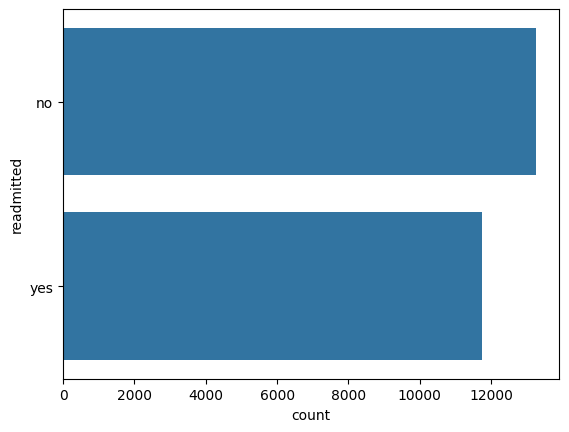

In [10]:
sns.countplot(df["readmitted"])

In [11]:
df

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,[80-90),14,77,1,30,0,0,0,Missing,Circulatory,Other,Circulatory,no,normal,no,no,yes
24996,[80-90),2,66,0,24,0,0,0,Missing,Digestive,Injury,Other,no,high,yes,yes,yes
24997,[70-80),5,12,0,6,0,1,0,Missing,Other,Other,Other,normal,no,no,no,yes
24998,[70-80),2,61,3,15,0,0,0,Family/GeneralPractice,Respiratory,Diabetes,Other,no,no,yes,yes,no


In [12]:
df_dup=df.drop_duplicates()
df_dup.shape

(25000, 17)

In [13]:
df_dup['n_inpatient'].value_counts()

n_inpatient
0     16537
1      4926
2      1909
3       833
4       358
5       211
6       104
7        47
8        26
9        20
10       12
11        8
12        3
14        2
15        2
13        2
Name: count, dtype: int64

In [14]:
df_dup['n_outpatient'].value_counts()

n_outpatient
0     20859
1      2076
2       913
3       537
4       269
5       136
6        74
7        39
8        18
11       16
9        13
10       12
13        7
14        7
12        6
15        5
21        3
27        2
16        2
20        2
18        2
33        1
23        1
Name: count, dtype: int64

In [15]:
df["medical_specialty"].value_counts()

medical_specialty
Missing                   12382
InternalMedicine           3565
Other                      2664
Emergency/Trauma           1885
Family/GeneralPractice     1882
Cardiology                 1409
Surgery                    1213
Name: count, dtype: int64

In [16]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df_dup['readmitted']=le.fit_transform(df_dup['readmitted'])
df_dup['readmitted']

0        0
1        0
2        1
3        1
4        0
        ..
24995    1
24996    1
24997    1
24998    0
24999    1
Name: readmitted, Length: 25000, dtype: int64

In [18]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df_dup['age']=oe.fit_transform(df_dup['age'].values.reshape(-1,1))
df_dup['age']

0        3.0
1        3.0
2        1.0
3        3.0
4        2.0
        ... 
24995    4.0
24996    4.0
24997    3.0
24998    3.0
24999    1.0
Name: age, Length: 25000, dtype: float64

In [20]:
# Encode remaining categorical columns
from sklearn.preprocessing import LabelEncoder

# Create a copy to work with
df_encoded = df_dup.copy()

# Define yes/no columns to encode (0 = no, 1 = yes)
yes_no_cols = ['glucose_test', 'A1Ctest', 'change', 'diabetes_med', 'readmitted']

# Encode yes/no columns
for col in yes_no_cols:
    if col in df_encoded.columns:
        df_encoded[col] = (df_encoded[col] == 'yes').astype(int)

# Encode medical_specialty using LabelEncoder
if 'medical_specialty' in df_encoded.columns:
    le_specialty = LabelEncoder()
    df_encoded['medical_specialty'] = le_specialty.fit_transform(df_encoded['medical_specialty'].astype(str))

# Encode diagnosis columns (diag_1, diag_2, diag_3) using LabelEncoder
diag_cols = ['diag_1', 'diag_2', 'diag_3']
for col in diag_cols:
    if col in df_encoded.columns:
        le_diag = LabelEncoder()
        df_encoded[col] = le_diag.fit_transform(df_encoded[col].astype(str))

print("Categorical encoding completed!")
print("\nEncoded dataframe info:")
print(df_encoded.info())
print("\nEncoded dataframe sample:")
df_encoded.head()

Categorical encoding completed!

Encoded dataframe info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                25000 non-null  float64
 1   time_in_hospital   25000 non-null  int64  
 2   n_lab_procedures   25000 non-null  int64  
 3   n_procedures       25000 non-null  int64  
 4   n_medications      25000 non-null  int64  
 5   n_outpatient       25000 non-null  int64  
 6   n_inpatient        25000 non-null  int64  
 7   n_emergency        25000 non-null  int64  
 8   medical_specialty  25000 non-null  int64  
 9   diag_1             25000 non-null  int64  
 10  diag_2             25000 non-null  int64  
 11  diag_3             25000 non-null  int64  
 12  glucose_test       25000 non-null  int64  
 13  A1Ctest            25000 non-null  int64  
 14  change             25000 non-null  int64  
 15  diabetes_med 

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,3.0,8,72,1,18,2,0,0,4,0,7,6,0,0,0,1,0
1,3.0,3,34,2,13,0,0,0,5,6,6,6,0,0,0,1,0
2,1.0,5,45,0,18,0,0,0,4,0,0,0,0,0,1,1,0
3,3.0,2,36,0,12,1,0,0,4,0,6,1,0,0,1,1,0
4,2.0,1,42,0,7,0,0,0,3,6,0,7,0,0,0,1,0


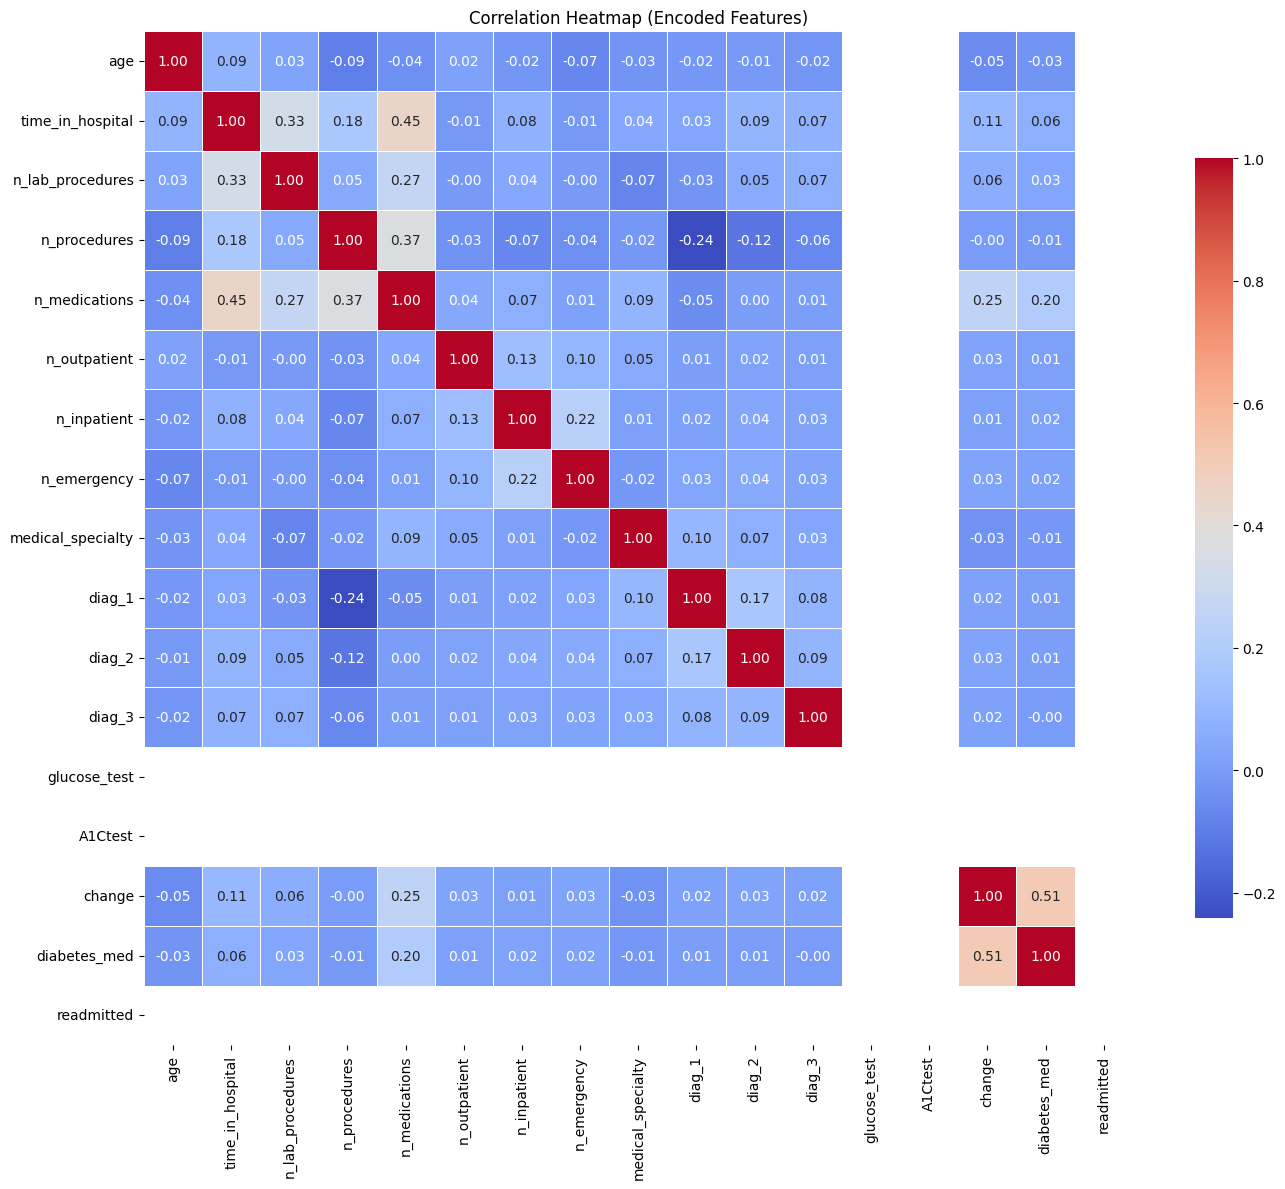

In [22]:
# Correlation heatmap for encoded numeric features
corr = df_encoded.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'shrink': 0.75})
plt.title('Correlation Heatmap (Encoded Features)')
plt.tight_layout()
plt.show()